# 08 · OpenRouter model economics and diffusion candidates

## Goal
Inspect a saved catalogue and perform cost arithmetic offline. No key is loaded and no network request is made.

**Status:** worked example prepared by Codex; learner understanding unassessed. No API calls.

## Setup
Run top to bottom. All examples are synthetic unless explicitly labelled as public evidence.

In [1]:
from pathlib import Path
import sys, json, tempfile
ROOT = Path.cwd()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
assert (ROOT / 'signal_lab').is_dir(), 'Run from the companion root or notebooks directory'
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.figsize': (8, 4.2), 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})


## Steps

### 1. Read the saved diffusion candidates
Catalogue prices are advertised metadata, not measured bills or quality evidence. Confirm availability again before paid experiments.

In [2]:
catalog=json.loads((ROOT/'data/openrouter_catalogue.json').read_text())
models=[m for m in catalog['data'] if m['id'].startswith('inception/')]
prices=pd.DataFrame([{'model':m['id'],'USD_per_million_input':float(m['pricing']['prompt'])*1e6,'USD_per_million_output':float(m['pricing']['completion'])*1e6,'context':m['context_length']} for m in models])
prices

,model,USD_per_million_input,USD_per_million_output,context
0,inception/mercury-2.5,0.04,0.15,260000
1,inception/mercury-2,0.25,0.75,128000


### 2. Calculate a token-only estimate
Assume 2,000 input and 300 output tokens per task, 40 tasks and three repeats. This excludes additional reasoning, retries, provider fees and uncertainty about actual tokenization. It is a scenario, not budget approval.

In [3]:
estimate=prices.copy()
estimate['scenario_USD']=(2000*estimate.USD_per_million_input+300*estimate.USD_per_million_output)/1e6*40*3
estimate[['model','scenario_USD']]

,model,scenario_USD
0,inception/mercury-2.5,0.015
1,inception/mercury-2,0.087


### 3. Cheaper tokens can produce more expensive completed work
The following model names and measurements are **invented**. There are 20 attempted tasks in each row, including failures in the total spend.

In [4]:
toy=pd.DataFrame({'fixture':['Cheap A','Stronger B'],'total_cost_USD':[.10,.16],'valid_tasks':[8,18]})
toy['cost_per_valid_task']=toy.total_cost_USD/toy.valid_tasks
toy

,fixture,total_cost_USD,valid_tasks,cost_per_valid_task
0,Cheap A,0.10,8,0.012500
1,Stronger B,0.16,18,0.008889


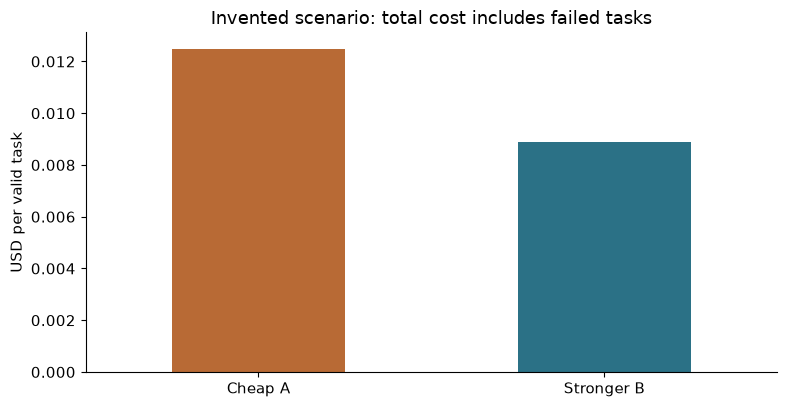

In [5]:
ax=toy.set_index('fixture').cost_per_valid_task.plot.bar(color=['#b86a35','#2b7186'])
ax.set(ylabel='USD per valid task',xlabel='',title='Invented scenario: total cost includes failed tasks')
plt.xticks(rotation=0);plt.tight_layout();plt.show()

### 4. Inspect the request without sending it

In [6]:
from signal_lab.openrouter import request_payload
request=request_payload('inception/mercury-2.5','Synthetic task: choose documents, data, both or clarify.','PROVIDER_TO_SELECT_AFTER_BUDGET_REVIEW')
{k:v for k,v in request.items() if k!='messages'}

{'model': 'inception/mercury-2.5',
 'stream': False,
 'max_tokens': 256,
 'temperature': 0.0,
 'provider': {'only': ['PROVIDER_TO_SELECT_AFTER_BUDGET_REVIEW'],
  'allow_fallbacks': False,
  'require_parameters': True,
  'data_collection': 'deny',
  'max_price': {'prompt': 1.0, 'completion': 2.0, 'request': 0}}}

## Checks
The adapter does not send this request. There is no latency or quality ranking of actual models. Compare role-specific quality and errors before cost; diffusion architecture is not a guarantee.

## Next Steps
Choose task cases before models. Agree a spending cap and provider pair before live calls. Non-streaming completion latency cannot be reported as time to first token.

**Low energy:** stop here. The checkpoint is optional; reading the worked output does not update mastery.